<a href="https://colab.research.google.com/github/dwmhr12/Nike_Run_Club_Tugas/blob/main/04_EDA_After_Preprocessing_Nike_Run_Club_Review_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

df_nike_reviews2.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103138 entries, 0 to 103137
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103138 non-null  object 
 1   score                   103138 non-null  int64  
 2   thumbsUpCount           103138 non-null  int64  
 3   reviewCreatedVersion    103138 non-null  object 
 4   at                      103138 non-null  object 
 5   appVersion              103138 non-null  object 
 6   id                      103138 non-null  int64  
 7   sentiment_polarity      103138 non-null  float64
 8   sentiment_subjectivity  103138 non-null  float64
 9   sentiment_rating        103138 non-null  object 
 10  final_cleaned           103138 non-null  object 
 11  token                   103138 non-null  object 
 12  token_after_sr          103138 non-null  object 
 13  lemmatized_tokens       103138 non-null  object 
 

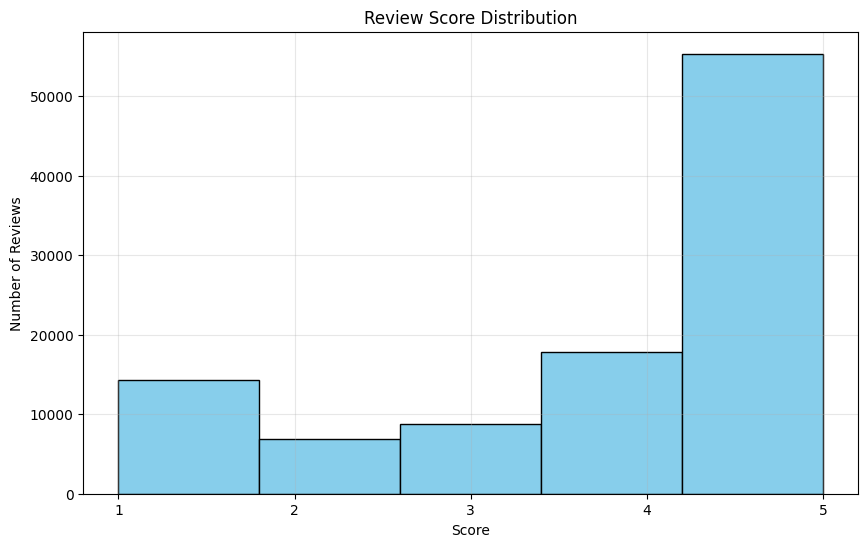

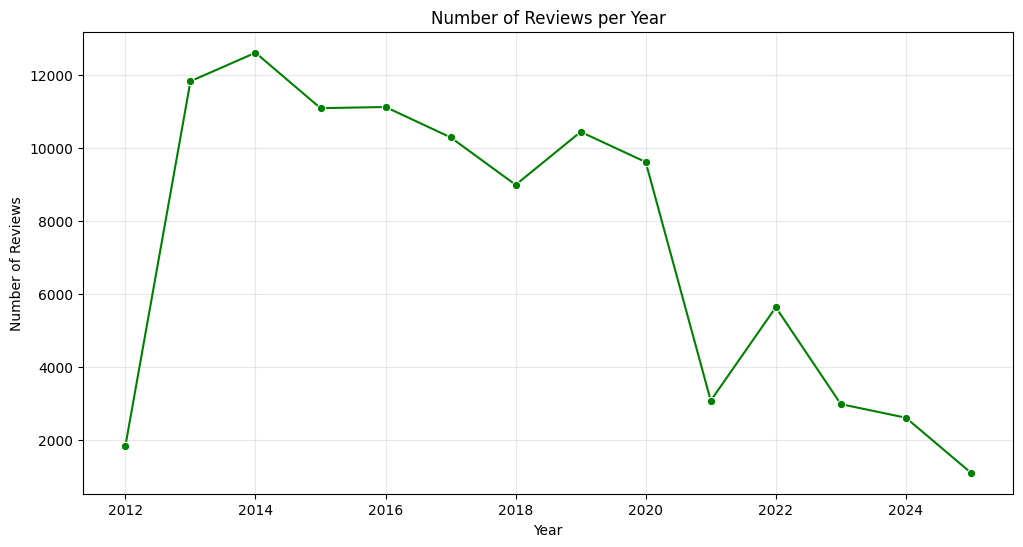

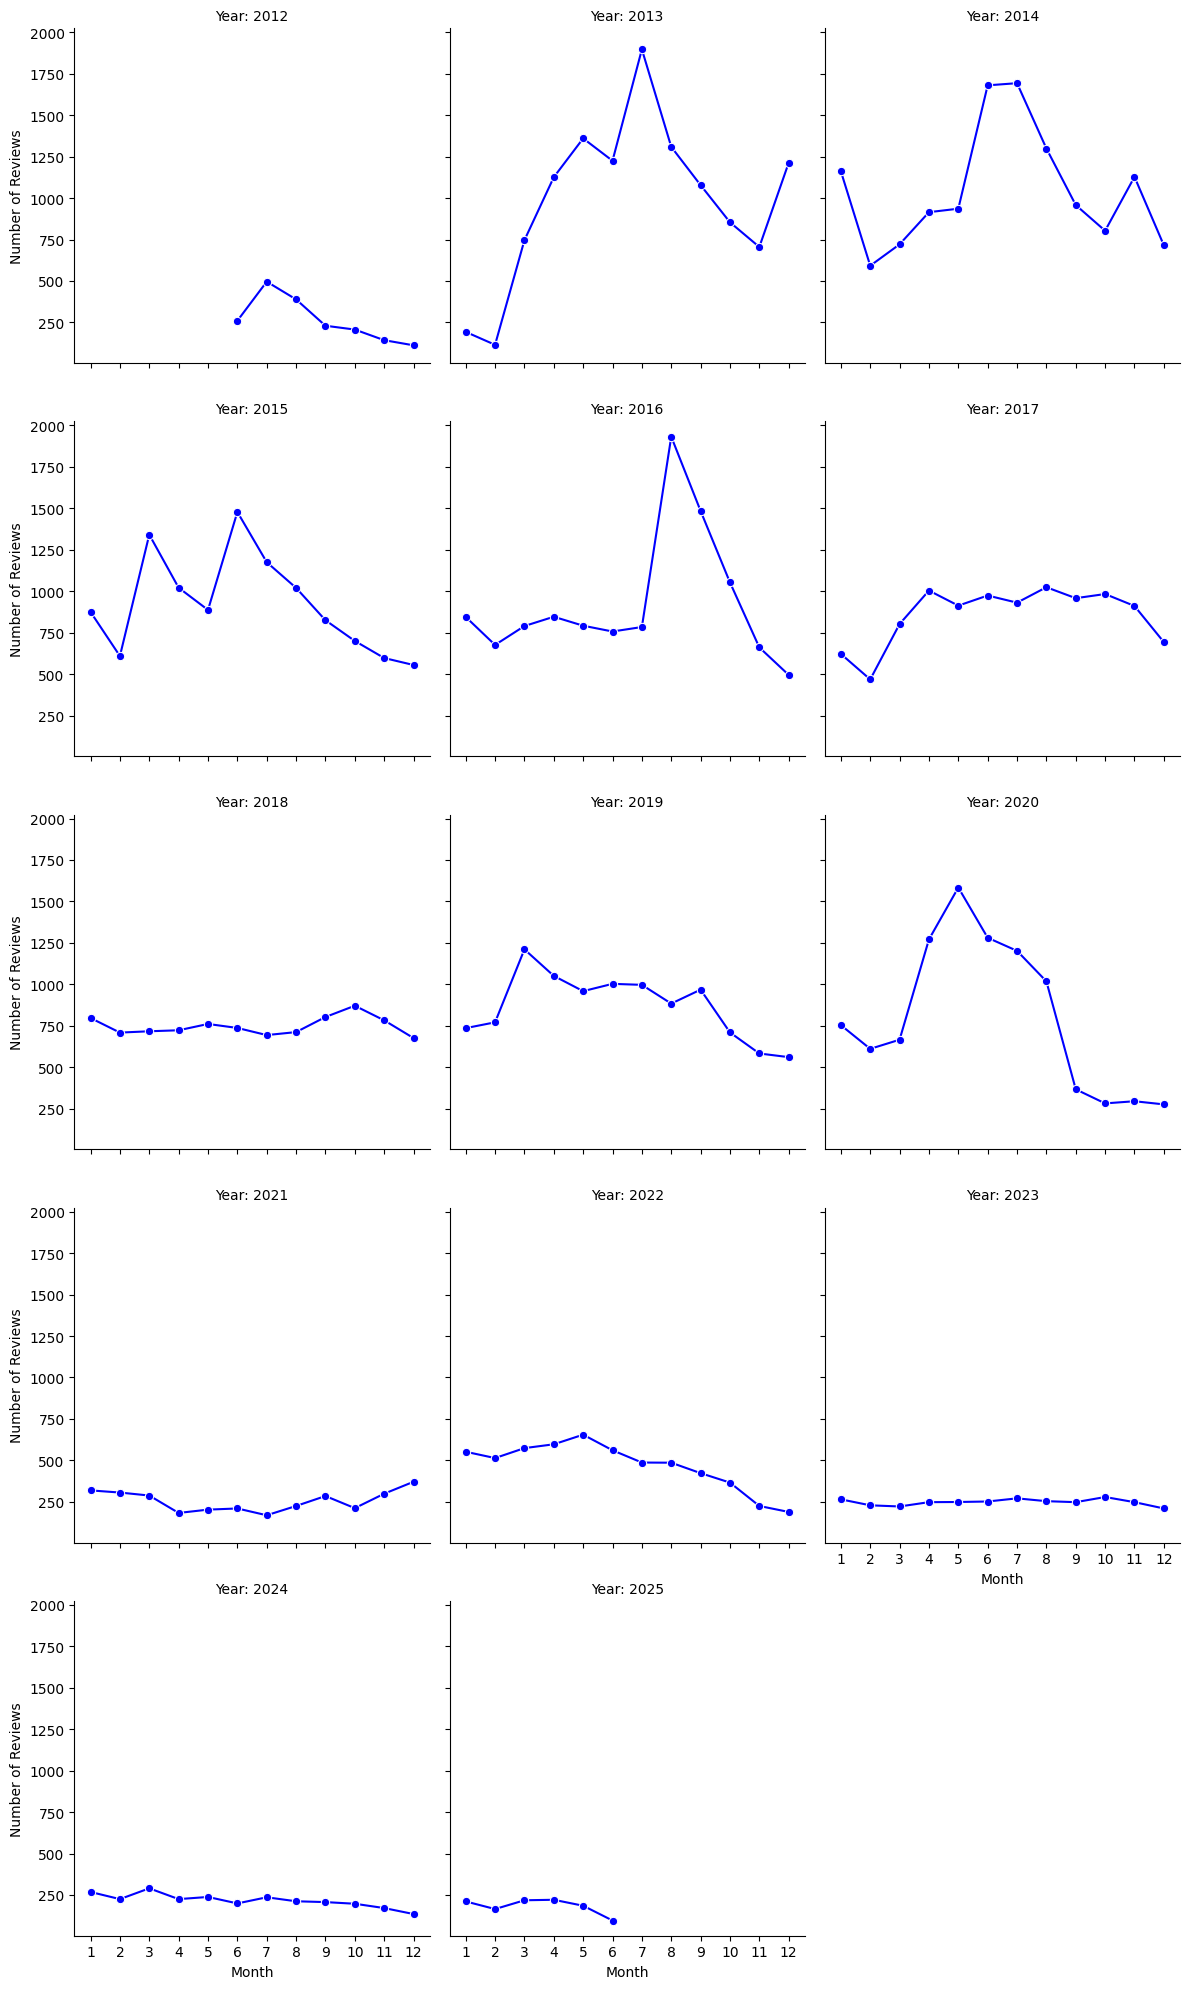

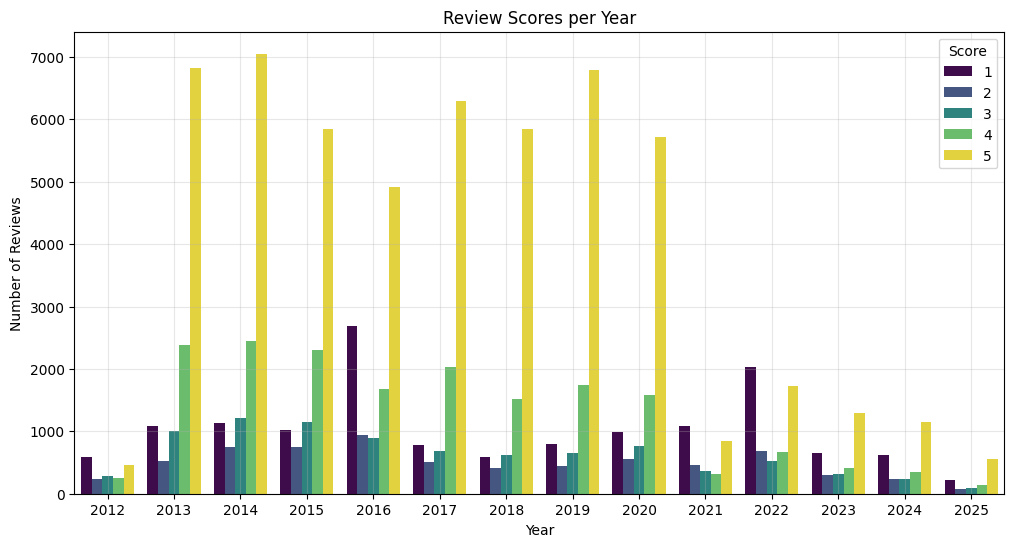


Score per Year:
score     1    2     3     4     5
year                              
2012    596  242   290   253   456
2013   1079  524  1009  2382  6827
2014   1134  745  1217  2454  7052
2015   1026  748  1148  2309  5852
2016   2691  939   886  1677  4922
2017    783  504   681  2024  6291
2018    593  412   613  1516  5849
2019    799  438   657  1742  6798
2020    987  555   758  1584  5723
2021   1087  461   370   310   842
2022   2029  679   518   670  1733
2023    649  306   312   415  1293
2024    628  235   238   346  1156
2025    218   80    99   144   555
Frasa negatif dengan kata positif: {'without great love', 'without gas good', 'without good', 'without great', 'without problem amazing'}


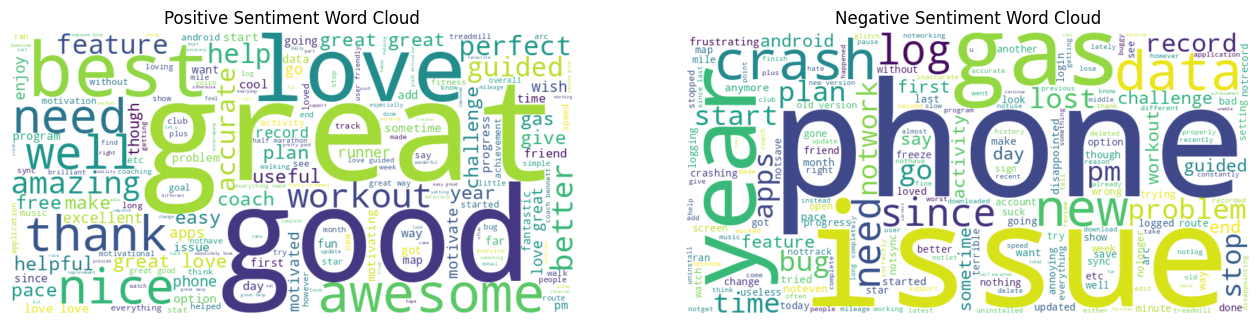

Mounted at /content/drive
DataFrame telah disimpan ke Google Drive sebagai df_nike_reviews2_eda.csv


In [2]:
# Exploratory Data Analysis (EDA) untuk df_nike_reviews2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords

# Unduh stopwords jika belum ada
try:
    nltk.download('stopwords', quiet=True)
except Exception as e:
    print(f"Error mengunduh stopwords: {e}")

# Muat data dari df_nike_reviews2.csv dengan penanganan error
try:
    df_nike_reviews2 = pd.read_csv('df_nike_reviews2.csv', on_bad_lines='skip', quotechar='"', encoding='utf-8')
    print("df_nike_reviews2.info()")
    df_nike_reviews2.info()
except Exception as e:
    print(f"Error memuat file CSV: {e}")
    print("Silakan periksa file df_nike_reviews2.csv atau regenerasi file dengan preprocessing yang diperbarui.")
    exit()

# Review Score Distribution
if 'df_nike_reviews2' in locals():
    plt.figure(figsize=(10, 6))
    plt.hist(df_nike_reviews2['score'], bins=5, color='skyblue', edgecolor='black')
    plt.title('Review Score Distribution')
    plt.xlabel('Score')
    plt.ylabel('Number of Reviews')
    plt.xticks(range(1, 6))
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("DataFrame tidak tersedia, tidak bisa membuat histogram.")

# Jumlah review per tahun
if 'df_nike_reviews2' in locals():
    df_nike_reviews2['at'] = pd.to_datetime(df_nike_reviews2['at'])
    df_nike_reviews2['year'] = df_nike_reviews2['at'].dt.year
    year_counts = df_nike_reviews2['year'].value_counts().sort_index()
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
    plt.title('Number of Reviews per Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Reviews')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("DataFrame tidak tersedia, tidak bisa membuat plot per tahun.")

# Jumlah review tiap bulan di setiap tahun
if 'df_nike_reviews2' in locals():
    df_nike_reviews2['month'] = df_nike_reviews2['at'].dt.month
    reviews_per_month = df_nike_reviews2.groupby(['year', 'month'])['id'].count().reset_index()
    g = sns.FacetGrid(reviews_per_month, col='year', col_wrap=3, height=4, sharey=True)
    g.map(sns.lineplot, 'month', 'id', marker='o', color='blue')
    g.set_axis_labels("Month", "Number of Reviews")
    g.set_titles("Year: {col_name}")
    plt.xticks(range(1, 13))
    plt.show()
else:
    print("DataFrame tidak tersedia, tidak bisa membuat plot per bulan.")

# Score per Year
if 'df_nike_reviews2' in locals():
    score_per_year = df_nike_reviews2.groupby(['year', 'score'])['id'].count().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(x='year', y='id', hue='score', data=score_per_year, palette='viridis')
    plt.xlabel('Year')
    plt.ylabel('Number of Reviews')
    plt.title('Review Scores per Year')
    plt.legend(title='Score')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Tabel Score per Year
    score_per_year_table = df_nike_reviews2.groupby('year')['score'].value_counts().unstack(fill_value=0)
    print("\nScore per Year:")
    print(score_per_year_table)
else:
    print("DataFrame tidak tersedia, tidak bisa membuat plot atau tabel skor per tahun.")

# WordCloud untuk sentimen positif dan negatif
if 'df_nike_reviews2' in locals():
    english_stopwords = set(stopwords.words('english'))
    positive_words = {'good', 'great', 'excellent', 'awesome', 'fantastic', 'amazing', 'best', 'nice', 'love', 'perfect'}
    negative_markers = {'not', 'never', 'barely', 'hardly', 'no', 'without'}

    all_stopwords = english_stopwords.union(positive_words)

    # Pisahkan review positif dan negatif, hapus NaN
    positive_reviews = df_nike_reviews2[df_nike_reviews2['sentiment_rating'] == 'Positive']['cleaned_text'].dropna()
    negative_reviews = df_nike_reviews2[df_nike_reviews2['sentiment_rating'] == 'Negative']['cleaned_text'].dropna()

    frasa_negatif_kompleks = []
    for review in negative_reviews:
        if pd.notna(review):  # Pastikan review bukan NaN
            words = review.split()
            for i in range(len(words)):
                if i < len(words) - 1 and words[i] in negative_markers and words[i + 1] in positive_words:
                    frasa_negatif_kompleks.append(f"{words[i]} {words[i + 1]}")
                if i < len(words) - 2 and words[i] in negative_markers and words[i + 2] in positive_words:
                    frasa_negatif_kompleks.append(f"{words[i]} {words[i + 1]} {words[i + 2]}")

    print("Frasa negatif dengan kata positif:", set(frasa_negatif_kompleks))
    all_stopwords = all_stopwords.union(set(frasa_negatif_kompleks))

    positive_wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=english_stopwords).generate(' '.join(positive_reviews))
    negative_wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=all_stopwords).generate(' '.join(negative_reviews))

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.imshow(positive_wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Positive Sentiment Word Cloud")

    plt.subplot(1, 2, 2)
    plt.imshow(negative_wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Negative Sentiment Word Cloud")

    plt.show()
else:
    print("DataFrame tidak tersedia, tidak bisa membuat WordCloud.")

# Simpan ke Google Drive (opsional)
if 'df_nike_reviews2' in locals():
    from google.colab import drive
    drive.mount('/content/drive')
    df_nike_reviews2.to_csv('/content/drive/My Drive/df_nike_reviews2_eda.csv', index=False)
    print("DataFrame telah disimpan ke Google Drive sebagai df_nike_reviews2_eda.csv")
else:
    print("DataFrame tidak tersedia, tidak bisa menyimpan ke Google Drive.")